**Name: Chirayu Pritmani**

**Roll No: 23102C0085**

**Branch: CMPN[C]**

**Sub: R Programming**




## 1. Aim
To develop an end-to-end, machine-learning-based analytics solution in **R** that
1. pre-processes the UCI *Online Retail* transaction data and engineers customer-level features (RFM, average order value, quantity, purchase frequency);
2. segments customers using **K-Means** (Elbow Method) and compares the result with **Hierarchical Clustering** (dendrogram) using the **Silhouette Score**;
3. visualises segments using **PCA** (2D static and 3D interactive Plotly);
4. profiles each segment and identifies the **high-value customer segment**;
5. builds **Random Forest** and **SVM** classifiers to predict high-value customers and compares them using Accuracy, Precision, Recall, F1-Score, ROC-AUC and Confusion Matrix;
6. interprets the results and recommends **segment-wise marketing strategies**.

## 2. Problem Statement
An e-commerce company wants to better understand its customers and improve its marketing decisions. Using historical online-retail transaction data, develop a machine-learning solution that identifies meaningful customer segments and predicts whether a customer is likely to belong to the high-value category.

## 3. Theory
**RFM analysis.** *Recency* = days since the last purchase, *Frequency* = number of distinct orders, *Monetary* = total spend. RFM is the standard behavioural summary of a customer.

**K-Means clustering.** Partitions *n* observations into *k* clusters by minimising the within-cluster sum of squares (WCSS): $\sum_{i=1}^{k}\sum_{x\in C_i}\lVert x-\mu_i\rVert^2$. It is distance-based, so features must be scaled and outliers treated.

**Elbow Method.** WCSS is plotted against *k*; the "elbow" where the decrease flattens indicates a good number of clusters.

**Hierarchical clustering & dendrogram.** Agglomerative clustering starts with each point as its own cluster and repeatedly merges the two closest clusters (here Ward's linkage, which minimises the increase in variance). The dendrogram shows merge heights; cutting it at a height yields *k* clusters.

**Silhouette Score.** For a point *i*, $s(i)=\dfrac{b(i)-a(i)}{\max(a(i),b(i))}$ where *a* is the mean distance to its own cluster and *b* the mean distance to the nearest other cluster. Values near +1 mean well-separated clusters; near 0 overlapping clusters.

**Principal Component Analysis (PCA).** Orthogonal linear transformation onto directions (principal components) of maximum variance. Used here to project the customer features to 2D/3D for visualisation.

**Random Forest.** Ensemble of decision trees trained on bootstrap samples with random feature subsets; predictions are averaged/voted. Provides feature importance (Mean Decrease in Gini/Accuracy).

**Support Vector Machine (SVM).** Finds the maximum-margin separating hyperplane; with an RBF kernel it handles non-linear boundaries. Requires scaled features.

**Evaluation metrics.** Accuracy = (TP+TN)/N; Precision = TP/(TP+FP); Recall = TP/(TP+FN); F1 = 2PR/(P+R); ROC-AUC = area under the TPR-vs-FPR curve; the Confusion Matrix tabulates TP, FP, TN, FN.

## 4. Dataset Description
**UCI Machine Learning Repository – Online Retail** (541,909 transactions of a UK-based online retailer, Dec 2010 – Dec 2011).

| Attribute | Description |
|---|---|
| InvoiceNo | Invoice number; a leading **'C'** marks a cancellation |
| StockCode | Product code |
| Description | Product name |
| Quantity | Units per transaction |
| InvoiceDate | Date and time of the invoice |
| UnitPrice | Price per unit (£) |
| CustomerID | Customer identifier (≈25 % missing) |
| Country | Customer's country |

## 5. Setup – install and load packages

In [ ]:
# (Colab) pandoc is needed to embed the interactive Plotly chart in the notebook
try(system("apt-get -qq install -y pandoc > /dev/null 2>&1"), silent = TRUE)

pkgs <- c("readxl","dplyr","tidyr","ggplot2","cluster","randomForest",
          "e1071","pROC","plotly","htmlwidgets","gridExtra","scales")
new  <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(new)) install.packages(new, quiet = TRUE, Ncpus = 4)
invisible(lapply(pkgs, library, character.only = TRUE))
options(repr.plot.width = 9, repr.plot.height = 5.5, timeout = 600)
set.seed(42)
cat("All packages loaded.\n")

also installing the dependencies ‘lazyeval’, ‘proxy’, ‘crosstalk’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var



Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    l

All packages loaded.


## 6. Data Loading

In [ ]:
dir.create("data", showWarnings = FALSE)
xlsx <- "data/Online Retail.xlsx"

if (!file.exists(xlsx)) {
  ok <- tryCatch({
    download.file("https://archive.ics.uci.edu/static/public/352/online+retail.zip",
                  "data/online_retail.zip", mode = "wb", quiet = TRUE)
    unzip("data/online_retail.zip", exdir = "data"); TRUE
  }, error = function(e) FALSE, warning = function(w) FALSE)
  if (!ok) {   # fallback: old UCI URL
    try(download.file("https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx",
                      xlsx, mode = "wb", quiet = TRUE), silent = TRUE)
  }
}
if (!file.exists(xlsx))
  stop("Download failed. Download 'Online Retail.xlsx' from the UCI repository, upload it to Colab (left panel -> Files) inside a folder called 'data', and re-run.")

raw <- read_excel(xlsx)
raw$InvoiceNo <- as.character(raw$InvoiceNo)
cat("Rows:", nrow(raw), " Columns:", ncol(raw), "\n")
str(raw)
head(raw)

Rows: 541909  Columns: 8 
tibble [541,909 × 8] (S3: tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: POSIXct[1:541909], format: "2010-12-01 08:26:00" "2010-12-01 08:26:00" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...


InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom


## 7. Data Preprocessing

Steps applied: (1) inspect missing values, (2) drop rows without `CustomerID`, (3) separate **cancellations** (InvoiceNo starting with "C") – removed from sales but counted per customer as a feature, (4) remove non-positive quantity/price, non-product stock codes and duplicates, (5) compute `TotalPrice = Quantity × UnitPrice`.

In [ ]:
cat("Missing values per column:\n"); print(colSums(is.na(raw)))
cat("\nCancelled invoice lines:", sum(startsWith(raw$InvoiceNo, "C")), "\n")

# cancellations per customer (kept as a behavioural feature)
cancel_by_cust <- raw %>%
  filter(!is.na(CustomerID), startsWith(InvoiceNo, "C")) %>%
  group_by(CustomerID) %>% summarise(Cancellations = n_distinct(InvoiceNo), .groups = "drop") %>%
  mutate(CustomerID = as.character(CustomerID))

non_product <- c("POST","D","M","DOT","CRUK","BANK CHARGES","AMAZONFEE","S","B","C2","AMAZONFEE")

df <- raw %>%
  filter(!is.na(CustomerID),
         !startsWith(InvoiceNo, "C"),
         Quantity > 0, UnitPrice > 0,
         !StockCode %in% non_product) %>%
  distinct() %>%
  mutate(CustomerID = as.character(CustomerID),
         TotalPrice = Quantity * UnitPrice)

cat("Rows after cleaning:", nrow(df), "\n")
cat("Unique customers   :", n_distinct(df$CustomerID), "\n")
cat("Date range         :", format(min(df$InvoiceDate)), "to", format(max(df$InvoiceDate)), "\n")

Missing values per column:
  InvoiceNo   StockCode Description    Quantity InvoiceDate   UnitPrice 
          0           0        1454           0           0           0 
 CustomerID     Country 
     135080           0 

Cancelled invoice lines: 9288 
Rows after cleaning: 391153 
Unique customers   : 4334 
Date range         : 2010-12-01 08:26:00 to 2011-12-09 12:50:00 


## 8. Customer-Level Feature Engineering

In [ ]:
snapshot <- max(df$InvoiceDate) + 24*3600     # reference date = 1 day after last transaction

cust <- df %>%
  group_by(CustomerID) %>%
  summarise(
    Recency        = as.numeric(difftime(snapshot, max(InvoiceDate), units = "days")),
    Frequency      = n_distinct(InvoiceNo),
    Monetary       = sum(TotalPrice),
    TotalQuantity  = sum(Quantity),
    UniqueProducts = n_distinct(StockCode),
    FirstPurchase  = min(InvoiceDate),
    Country        = first(Country),
    .groups = "drop") %>%
  mutate(AvgOrderValue = Monetary / Frequency,                      # average transaction value
         AvgQuantity   = TotalQuantity / Frequency,                 # units per order
         TenureDays    = as.numeric(difftime(snapshot, FirstPurchase, units = "days")),
         PurchaseFreq  = Frequency / (TenureDays / 30 + 1)) %>%     # orders per month
  left_join(cancel_by_cust, by = "CustomerID") %>%
  mutate(Cancellations = ifelse(is.na(Cancellations), 0, Cancellations)) %>%
  select(-FirstPurchase)

feat_cols <- c("Recency","Frequency","Monetary","AvgOrderValue","TotalQuantity",
               "AvgQuantity","UniqueProducts","TenureDays","PurchaseFreq","Cancellations")
cat("Customers:", nrow(cust), "\n")
head(cust)
summary(cust[, feat_cols])

Customers: 4334 


CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,Country,AvgOrderValue,AvgQuantity,TenureDays,PurchaseFreq,Cancellations
<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12346,326.117361,1,77183.60,74215,1,United Kingdom,77183.6000,74215.00000,326.11736,0.08424189,1
12347,2.873611,7,4310.00,2458,103,Iceland,615.7143,351.14286,367.91181,0.52775514,0
12348,75.984028,4,1437.24,2332,21,Finland,359.3100,583.00000,358.73681,0.30869215,0
12349,19.124306,1,1457.55,630,72,Italy,1457.5500,630.00000,19.12431,0.61069566,0
12350,310.867361,1,294.40,196,16,Norway,294.4000,196.00000,310.86736,0.08801077,0
12352,36.925694,7,1385.74,526,57,Norway,197.9629,75.14286,297.01181,0.64217865,3


    Recency         Frequency          Monetary         AvgOrderValue     
 Min.   :  1.00   Min.   :  1.000   Min.   :     3.75   Min.   :    3.75  
 1st Qu.: 18.07   1st Qu.:  1.000   1st Qu.:   304.24   1st Qu.:  177.20  
 Median : 51.13   Median :  2.000   Median :   662.57   Median :  289.56  
 Mean   : 93.22   Mean   :  4.246   Mean   :  2015.97   Mean   :  415.48  
 3rd Qu.:143.08   3rd Qu.:  5.000   3rd Qu.:  1631.62   3rd Qu.:  423.41  
 Max.   :374.12   Max.   :206.000   Max.   :279138.02   Max.   :84236.25  
 TotalQuantity       AvgQuantity       UniqueProducts      TenureDays     
 Min.   :     1.0   Min.   :    1.00   Min.   :   1.00   Min.   :  1.024  
 1st Qu.:   159.2   1st Qu.:   92.53   1st Qu.:  16.00   1st Qu.:113.110  
 Median :   377.5   Median :  161.00   Median :  35.00   Median :249.123  
 Mean   :  1186.4   Mean   :  255.28   Mean   :  61.43   Mean   :223.825  
 3rd Qu.:   989.8   3rd Qu.:  271.98   3rd Qu.:  77.00   3rd Qu.:327.067  
 Max.   :196844.0   Max. 

## 9. Outlier Treatment, Transformation and Scaling

RFM variables are highly right-skewed. We (i) **winsorise** every feature at the 1st/99th percentile, (ii) apply a **log(1+x)** transform to reduce skewness, and (iii) **standardise** (z-score) the clustering features so that no variable dominates the Euclidean distance.

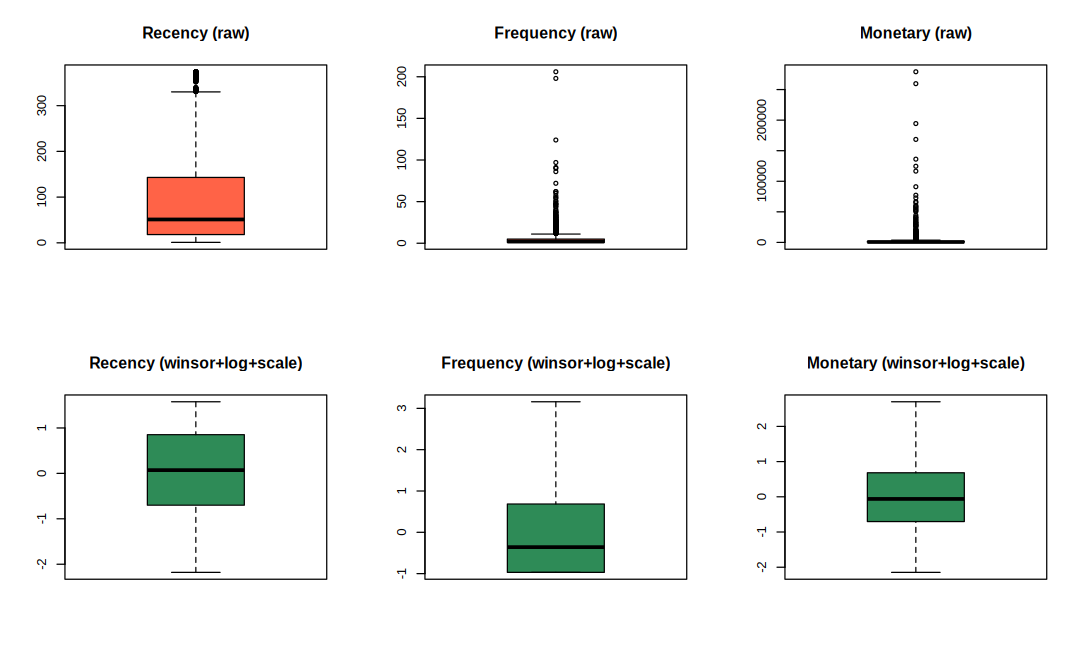

In [ ]:
winsor <- function(x) { q <- quantile(x, c(.01, .99)); pmin(pmax(x, q[1]), q[2]) }

cust_w   <- cust   %>% mutate(across(all_of(feat_cols), winsor))
cust_log <- cust_w %>% mutate(across(all_of(feat_cols), log1p))

cl_cols <- c("Recency", "Frequency", "Monetary")        # features used for clustering
X <- scale(cust_log[, cl_cols])                          # standardised matrix
dist_X <- dist(X)                                        # Euclidean distance matrix

par(mfrow = c(2, 3))
for (v in cl_cols) boxplot(cust[[v]], main = paste(v, "(raw)"), col = "tomato")
for (v in cl_cols) boxplot(as.numeric(X[, v]), main = paste(v, "(winsor+log+scale)"), col = "seagreen")
par(mfrow = c(1, 1))

## 10. K-Means Clustering – Elbow Method

Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”
Warning message:
“did not converge in 10 iterations”


   k    WSS Silhouette
1  2 6304.0     0.4357
2  3 4692.1     0.3398
3  4 3742.9     0.3375
4  5 3110.2     0.3193
5  6 2675.3     0.3167
6  7 2388.0     0.3093
7  8 2184.9     0.3055
8  9 2015.6     0.2850
9 10 1864.8     0.2837


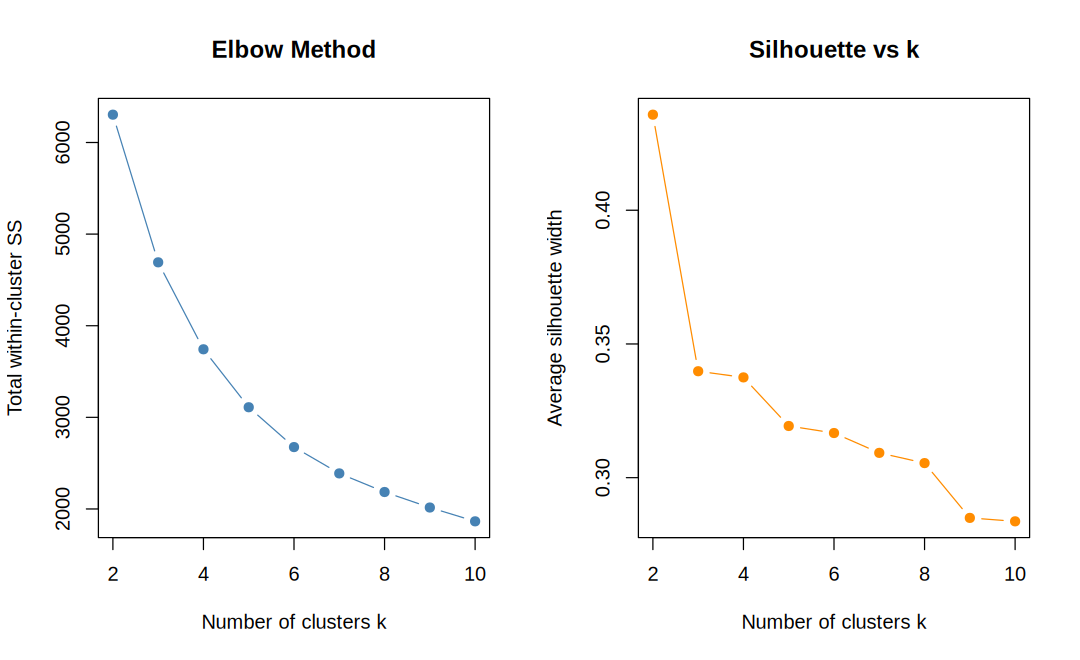

In [ ]:
ks  <- 2:10
wss <- sapply(ks, function(k) kmeans(X, centers = k, nstart = 25)$tot.withinss)
sil <- sapply(ks, function(k) {
  km <- kmeans(X, centers = k, nstart = 25)
  mean(silhouette(km$cluster, dist_X)[, 3])
})

par(mfrow = c(1, 2))
plot(ks, wss, type = "b", pch = 19, col = "steelblue", xlab = "Number of clusters k",
     ylab = "Total within-cluster SS", main = "Elbow Method")
plot(ks, sil, type = "b", pch = 19, col = "darkorange", xlab = "Number of clusters k",
     ylab = "Average silhouette width", main = "Silhouette vs k")
par(mfrow = c(1, 1))
print(data.frame(k = ks, WSS = round(wss, 1), Silhouette = round(sil, 4)))

**Choosing k.** The elbow flattens around k = 3–4 and gives interpretable business segments at k = 4. Change `K` below if your plot suggests otherwise.

In [ ]:
K <- 4
set.seed(42)
km <- kmeans(X, centers = K, nstart = 50)
sil_km <- mean(silhouette(km$cluster, dist_X)[, 3])
cat("K-Means cluster sizes:\n"); print(km$size)
cat("K-Means average silhouette score:", round(sil_km, 4), "\n")

K-Means cluster sizes:
[1]  753 1178  888 1515
K-Means average silhouette score: 0.3375 


## 11. Hierarchical Clustering and Dendrogram

Hierarchical cluster sizes:
hc_cl
   1    2    3    4 
1267  529 1672  866 
Hierarchical average silhouette score: 0.2767 


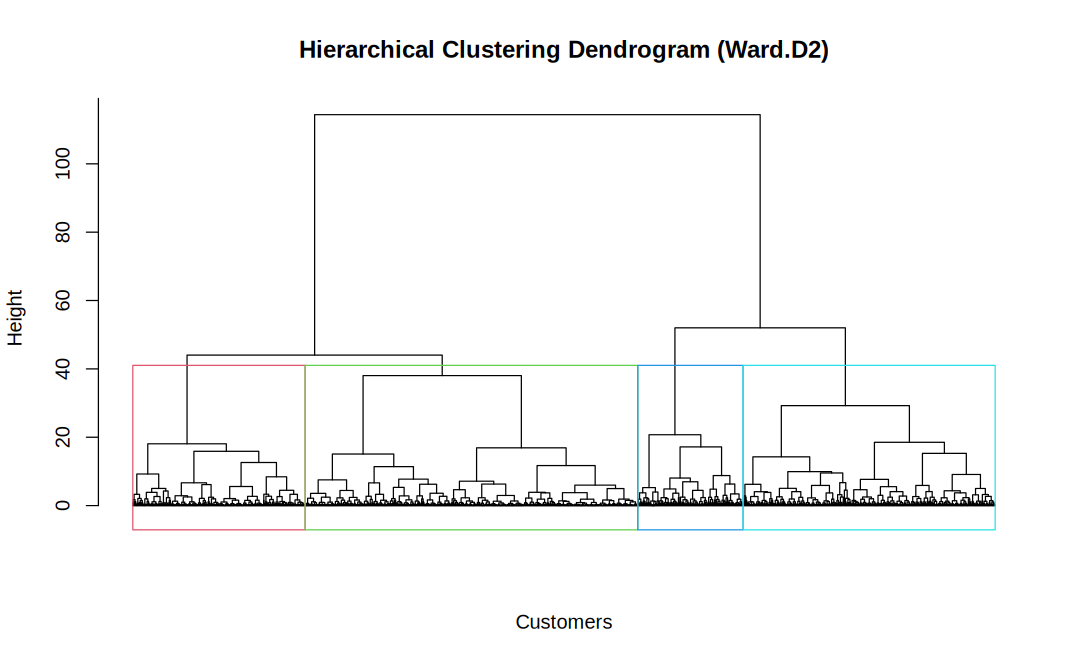

In [ ]:
hc <- hclust(dist_X, method = "ward.D2")
plot(hc, labels = FALSE, hang = -1, main = "Hierarchical Clustering Dendrogram (Ward.D2)",
     xlab = "Customers", sub = "")
rect.hclust(hc, k = K, border = 2:(K + 1))

hc_cl  <- cutree(hc, k = K)
sil_hc <- mean(silhouette(hc_cl, dist_X)[, 3])
cat("Hierarchical cluster sizes:\n"); print(table(hc_cl))
cat("Hierarchical average silhouette score:", round(sil_hc, 4), "\n")

## 12. Comparison of K-Means and Hierarchical Clustering

                  Method Silhouette Min_Cluster Max_Cluster
1                K-Means     0.3375         753        1515
2 Hierarchical (Ward.D2)     0.2767         529        1672

Adjusted Rand Index between the two solutions: 0.4188 

Cross-tabulation (rows = K-Means, columns = Hierarchical):
      Hierarchical
KMeans    1    2    3    4
     1  229  524    0    0
     2  788    5  384    1
     3  250    0   76  562
     4    0    0 1212  303


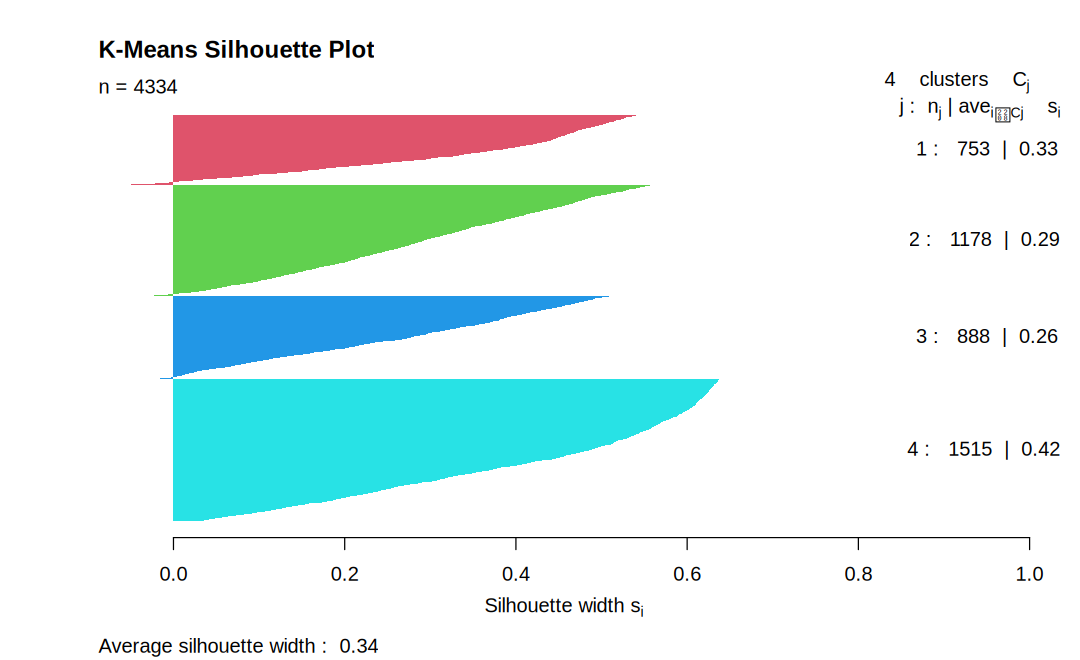

In [ ]:
ari <- function(a, b) {            # Adjusted Rand Index
  tab <- table(a, b); n <- sum(tab); sc <- function(x) sum(choose(x, 2))
  sa <- sc(rowSums(tab)); sb <- sc(colSums(tab)); sij <- sc(tab)
  e <- sa * sb / choose(n, 2); (sij - e) / (0.5 * (sa + sb) - e)
}
ari_val <- ari(km$cluster, hc_cl)

comparison <- data.frame(
  Method = c("K-Means", "Hierarchical (Ward.D2)"),
  Silhouette = round(c(sil_km, sil_hc), 4),
  Min_Cluster = c(min(km$size), min(table(hc_cl))),
  Max_Cluster = c(max(km$size), max(table(hc_cl))))
print(comparison)
cat("\nAdjusted Rand Index between the two solutions:", round(ari_val, 4), "\n")
cat("\nCross-tabulation (rows = K-Means, columns = Hierarchical):\n")
print(table(KMeans = km$cluster, Hierarchical = hc_cl))

# silhouette plot of K-Means
plot(silhouette(km$cluster, dist_X), col = 2:(K + 1), border = NA, main = "K-Means Silhouette Plot")

## 13. Cluster Profiling and Segment Naming

Clusters are ranked by a composite RFM score (low Recency is good; high Frequency and Monetary are good) and named accordingly. **Check the names against the profile table** – the numbers, not the labels, are the evidence.

                 Segment Cluster Customers  Pct Recency Frequency Monetary
1 Champions (High-Value)       1       753 17.4    12.6      13.2   7621.0
2        Loyal Customers       2      1178 27.2    69.7       4.0   1745.0
3   At-Risk / Occasional       3       888 20.5    22.6       1.9    472.2
4         Lost / Dormant       4      1515 35.0   193.0       1.3    345.7
  AvgOrderValue TotalQuantity UniqueProducts
1         603.3        4367.0          151.0
2         570.5        1081.4           72.8
3         273.0         293.3           37.7
4         285.1         210.6           21.9
                 Segment   Revenue Share
1 Champions (High-Value) 5738586.2  65.7
2        Loyal Customers 2055583.0  23.5
3   At-Risk / Occasional  419271.0   4.8
4         Lost / Dormant  523787.4   6.0


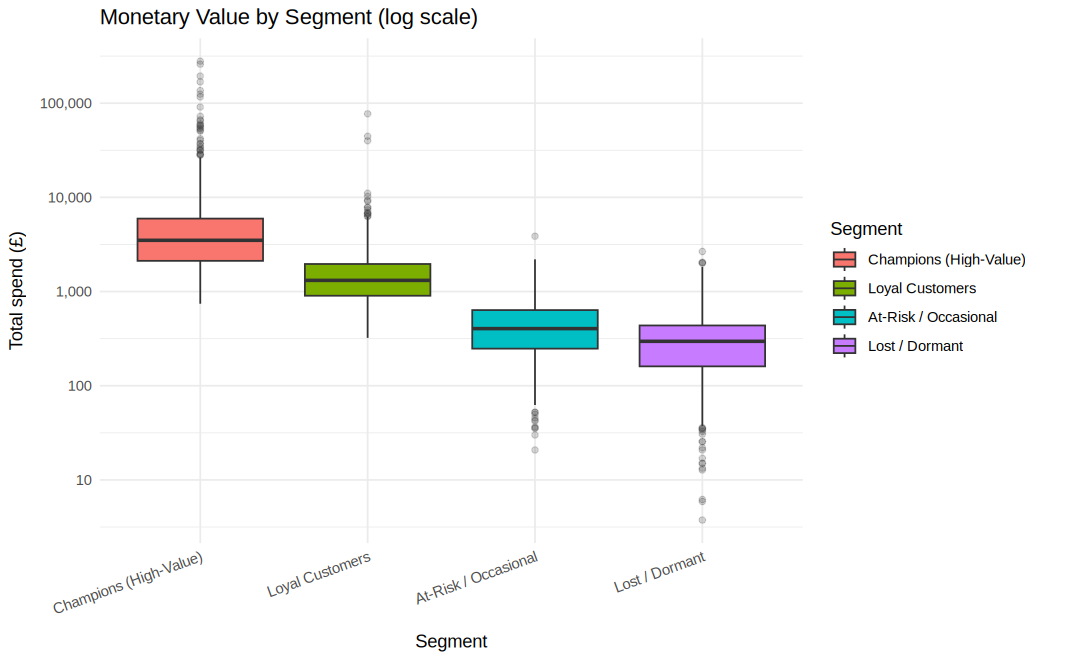

In [ ]:
cust$Cluster <- km$cluster

prof <- cust %>%
  group_by(Cluster) %>%
  summarise(Customers = n(), Pct = round(100 * n() / nrow(cust), 1),
            Recency = mean(Recency), Frequency = mean(Frequency), Monetary = mean(Monetary),
            AvgOrderValue = mean(AvgOrderValue), TotalQuantity = mean(TotalQuantity),
            UniqueProducts = mean(UniqueProducts), .groups = "drop") %>%
  mutate(score = rank(-Recency) + rank(Frequency) + rank(Monetary)) %>%
  arrange(desc(score))

seg_names <- if (K == 4) c("Champions (High-Value)", "Loyal Customers", "At-Risk / Occasional", "Lost / Dormant") else
             c("Champions (High-Value)", paste("Mid-Value Segment", seq_len(K - 2)), "Lost / Dormant")
prof$Segment <- seg_names
cust$Segment <- factor(prof$Segment[match(cust$Cluster, prof$Cluster)], levels = seg_names)
high_cluster <- prof$Cluster[1]

print(as.data.frame(prof %>% select(Segment, Cluster, Customers, Pct, Recency, Frequency, Monetary,
                                    AvgOrderValue, TotalQuantity, UniqueProducts) %>%
                      mutate(across(where(is.numeric), ~ round(.x, 1)))))

# Revenue contribution of each segment
rev <- cust %>% group_by(Segment) %>% summarise(Revenue = sum(Monetary), .groups = "drop") %>%
  mutate(Share = round(100 * Revenue / sum(Revenue), 1))
print(as.data.frame(rev))

ggplot(cust, aes(Segment, Monetary, fill = Segment)) + geom_boxplot(outlier.alpha = .2) +
  scale_y_log10(labels = comma) + theme_minimal() + theme(axis.text.x = element_text(angle = 20, hjust = 1)) +
  labs(title = "Monetary Value by Segment (log scale)", y = "Total spend (£)")

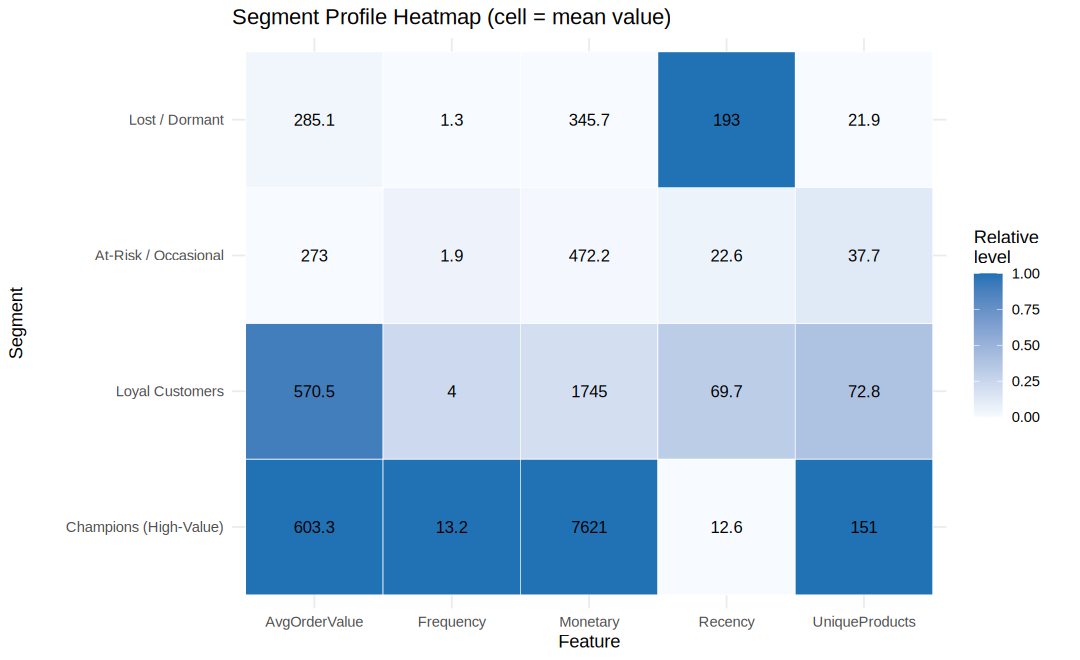

In [ ]:
long <- cust %>% select(Segment, Recency, Frequency, Monetary, AvgOrderValue, UniqueProducts) %>%
  pivot_longer(-Segment, names_to = "Feature", values_to = "Value") %>%
  group_by(Segment, Feature) %>% summarise(Mean = mean(Value), .groups = "drop") %>%
  group_by(Feature) %>% mutate(Scaled = (Mean - min(Mean)) / (max(Mean) - min(Mean)))

ggplot(long, aes(Feature, Segment, fill = Scaled)) + geom_tile(colour = "white") +
  geom_text(aes(label = round(Mean, 1)), size = 3.5) +
  scale_fill_gradient(low = "#f7fbff", high = "#2171b5", name = "Relative\nlevel") +
  theme_minimal() + labs(title = "Segment Profile Heatmap (cell = mean value)")

## 14. PCA – 2D Visualisation of Segments

                          PC1    PC2    PC3
Standard deviation     1.5036 0.7480 0.4239
Proportion of Variance 0.7536 0.1865 0.0599
Cumulative Proportion  0.7536 0.9401 1.0000

Loadings:
             PC1   PC2    PC3
Recency   -0.512 0.850  0.124
Frequency  0.618 0.264  0.741
Monetary   0.597 0.456 -0.660


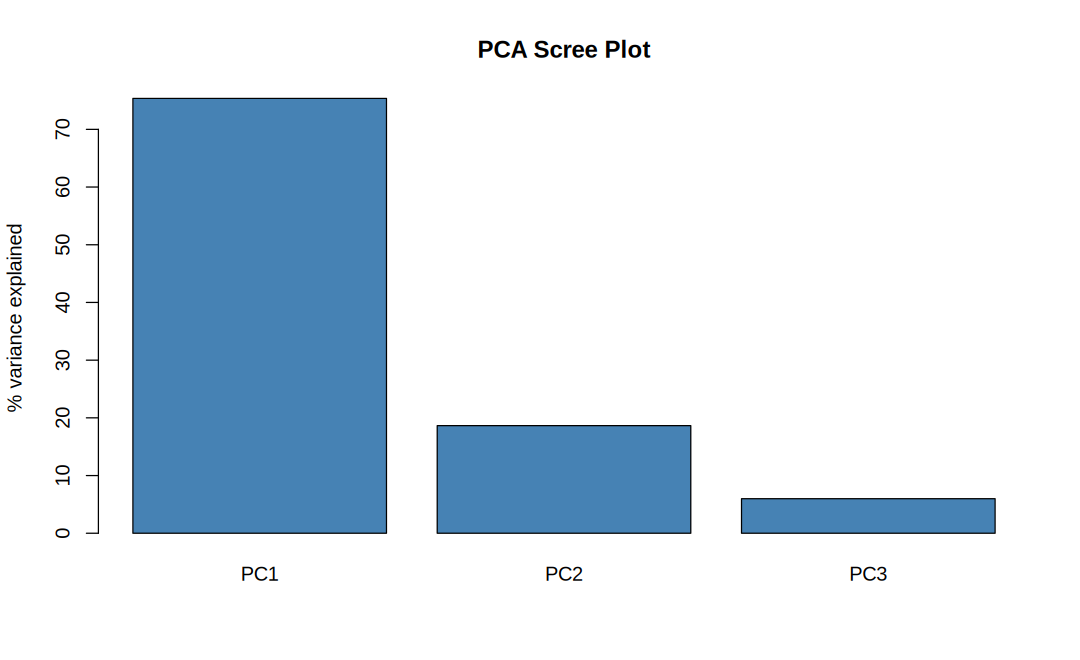

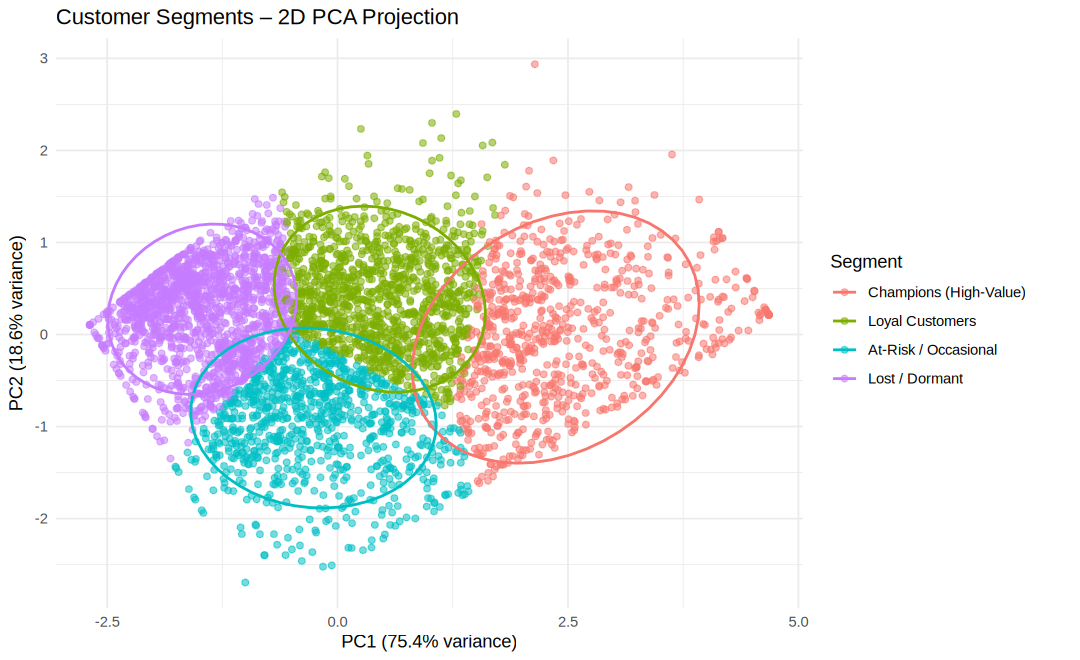

In [ ]:
pca <- prcomp(X, center = FALSE, scale. = FALSE)     # X is already standardised
var_exp <- summary(pca)$importance
print(round(var_exp, 4))
cat("\nLoadings:\n"); print(round(pca$rotation, 3))

barplot(var_exp[2, ] * 100, col = "steelblue", ylab = "% variance explained", main = "PCA Scree Plot")

pc <- data.frame(pca$x[, 1:3], Segment = cust$Segment)
ggplot(pc, aes(PC1, PC2, colour = Segment)) +
  geom_point(alpha = .55, size = 1.6) + stat_ellipse(level = .9, linewidth = .8) +
  theme_minimal() +
  labs(title = "Customer Segments – 2D PCA Projection",
       x = sprintf("PC1 (%.1f%% variance)", var_exp[2, 1] * 100),
       y = sprintf("PC2 (%.1f%% variance)", var_exp[2, 2] * 100))

## 15. Interactive 3D Visualisation (Plotly)

In [ ]:
p3d <- plot_ly(pc, x = ~PC1, y = ~PC2, z = ~PC3, color = ~Segment,
               type = "scatter3d", mode = "markers",
               marker = list(size = 3, opacity = .7),
               text = ~paste("Segment:", Segment)) %>%
  layout(title = "Interactive 3D PCA of Customer Segments",
         scene = list(xaxis = list(title = "PC1"), yaxis = list(title = "PC2"), zaxis = list(title = "PC3")))

htmlwidgets::saveWidget(p3d, "customer_clusters_3d.html", selfcontained = TRUE)   # also usable for your Git repo
tryCatch(
  IRdisplay::display_html(paste(readLines("customer_clusters_3d.html", warn = FALSE), collapse = "\n")),
  error = function(e) print(p3d))

<!DOCTYPE html>
 
 
 
 plotly

> *Note:* interactive widgets do not appear when a notebook is printed to PDF. For the PDF, keep the static PCA plot above and add a screenshot of this 3D plot; the file `customer_clusters_3d.html` is saved for your repository.

## 16. Predicting High-Value Customers – Supervised Learning

**Target:** `HighValue = Yes` if the customer belongs to the *Champions* cluster, else `No`.

**Avoiding target leakage.** The segment was *created* from Recency, Frequency and Monetary, so predicting it from those same variables would be circular. The classifiers therefore use only the *other* behavioural features (average order value, quantities, product variety, tenure, purchase rate, cancellations, recency-independent behaviour). Even so, these are correlated with spend, so high scores are expected; the model's value is showing which behaviours identify high-value customers, not discovering an unknown target.

In [ ]:
model_cols <- c("Recency", "AvgOrderValue", "TotalQuantity", "AvgQuantity",
                "UniqueProducts", "TenureDays", "PurchaseFreq", "Cancellations")
ml <- cust_log[, model_cols]
ml$HighValue <- factor(ifelse(cust$Cluster == high_cluster, "Yes", "No"), levels = c("No", "Yes"))
cat("Class balance:\n"); print(table(ml$HighValue)); print(round(prop.table(table(ml$HighValue)), 3))

# stratified 70/30 split
set.seed(42)
idx   <- unlist(lapply(split(seq_len(nrow(ml)), ml$HighValue), function(i) sample(i, round(0.7 * length(i)))))
train <- ml[idx, ];  test <- ml[-idx, ]
cat("\nTrain:", nrow(train), " Test:", nrow(test), "\n")

Class balance:

  No  Yes 
3581  753 

   No   Yes 
0.826 0.174 

Train: 3034  Test: 1300 


In [ ]:
# ---- Random Forest ----
set.seed(42)
rf <- randomForest(HighValue ~ ., data = train, ntree = 500, importance = TRUE)
rf_pred <- predict(rf, test)
rf_prob <- predict(rf, test, type = "prob")[, "Yes"]

# ---- SVM (RBF kernel; e1071 scales features using the training data) ----
set.seed(42)
svm_m <- svm(HighValue ~ ., data = train, kernel = "radial", cost = 1, gamma = 1 / length(model_cols),
             probability = TRUE)
sp       <- predict(svm_m, test, probability = TRUE)
svm_pred <- as.factor(sp)
svm_prob <- attr(sp, "probabilities")[, "Yes"]
print(rf)


Call:
 randomForest(formula = HighValue ~ ., data = train, ntree = 500,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 2

        OOB estimate of  error rate: 2.57%
Confusion matrix:
      No Yes class.error
No  2483  24 0.009573195
Yes   54 473 0.102466793


## 17. Model Evaluation and Comparison

In [ ]:
eval_model <- function(truth, pred, prob, name) {
  cm  <- table(Predicted = factor(pred, levels = c("No", "Yes")), Actual = factor(truth, levels = c("No", "Yes")))
  TP <- cm["Yes","Yes"]; TN <- cm["No","No"]; FP <- cm["Yes","No"]; FN <- cm["No","Yes"]
  prec <- TP / (TP + FP); rec <- TP / (TP + FN)
  roc_o <- roc(truth, prob, levels = c("No", "Yes"), direction = "<", quiet = TRUE)
  list(cm = cm, roc = roc_o,
       res = data.frame(Model = name, Accuracy = (TP + TN) / sum(cm), Precision = prec,
                        Recall = rec, F1 = 2 * prec * rec / (prec + rec), ROC_AUC = as.numeric(auc(roc_o))))
}
rf_e  <- eval_model(test$HighValue, rf_pred,  rf_prob,  "Random Forest")
svm_e <- eval_model(test$HighValue, svm_pred, svm_prob, "SVM (RBF)")

results <- rbind(rf_e$res, svm_e$res)
results[, -1] <- round(results[, -1], 4)
print(results, row.names = FALSE)

cat("\nConfusion Matrix - Random Forest\n"); print(rf_e$cm)
cat("\nConfusion Matrix - SVM\n");           print(svm_e$cm)

         Model Accuracy Precision Recall     F1 ROC_AUC
 Random Forest   0.9800    0.9762 0.9071 0.9404  0.9981
     SVM (RBF)   0.9869    0.9772 0.9469 0.9618  0.9994

Confusion Matrix - Random Forest
         Actual
Predicted   No  Yes
      No  1069   21
      Yes    5  205

Confusion Matrix - SVM
         Actual
Predicted   No  Yes
      No  1069   12
      Yes    5  214


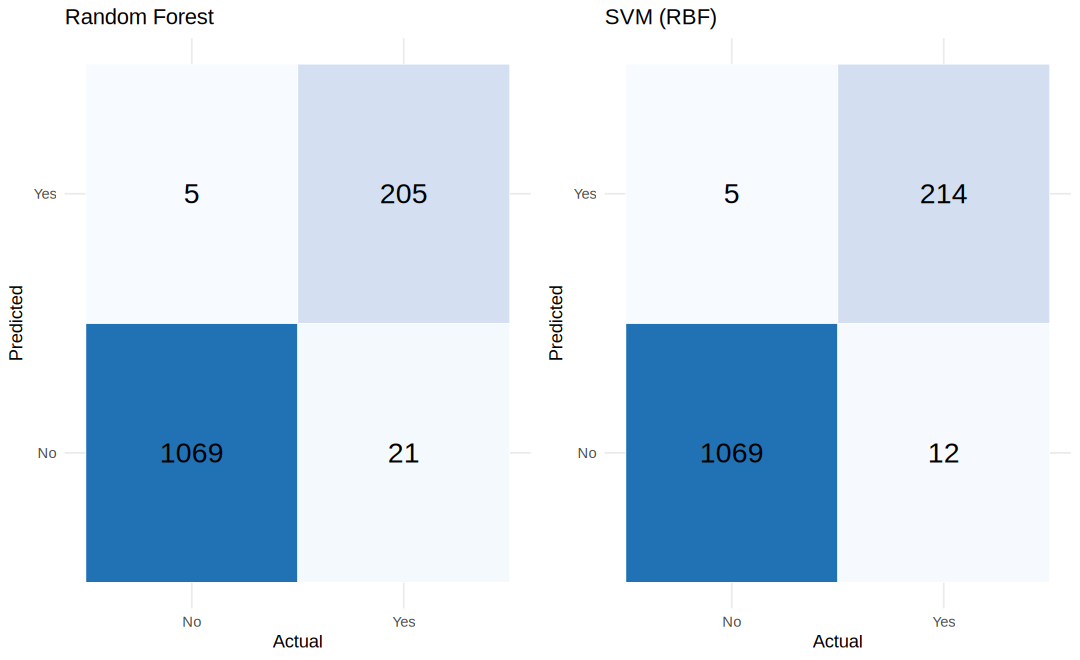

Warning message in sprintf(c("Random Forest (AUC = %.3f)", "SVM (AUC = %.3f)"), :
“one argument not used by format”


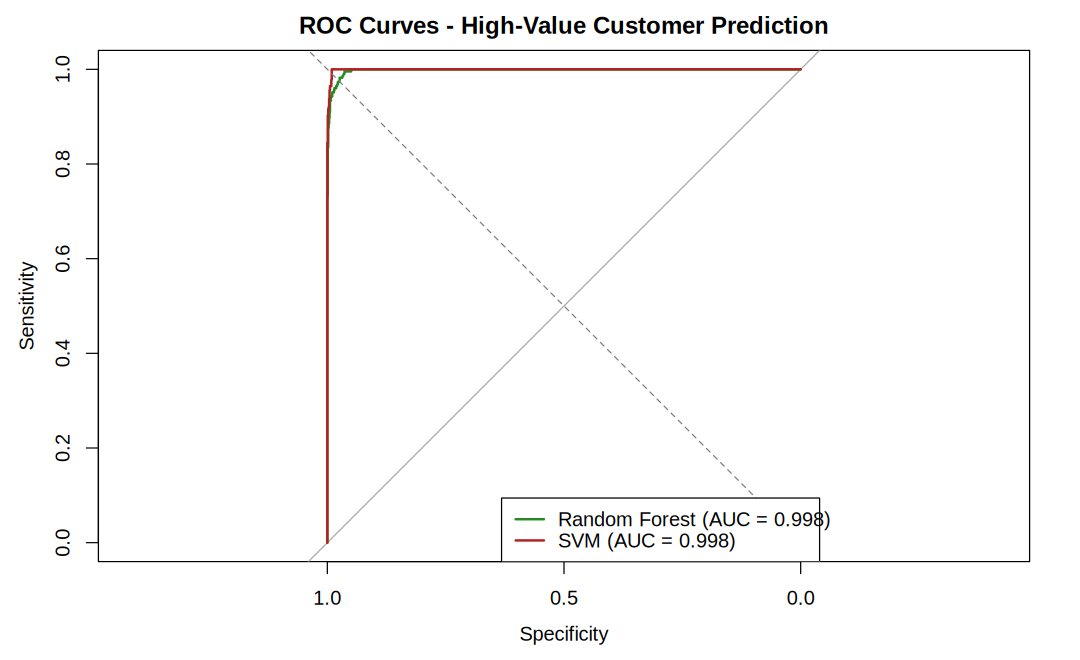

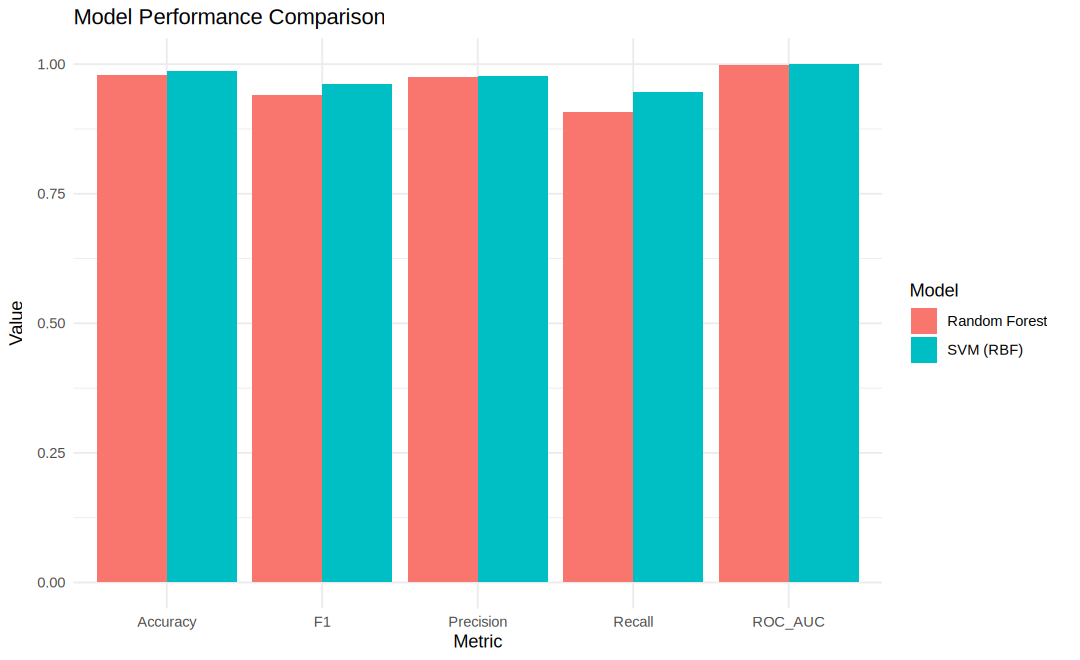

In [ ]:
cm_plot <- function(cm, title) {
  d <- as.data.frame(cm)
  ggplot(d, aes(Actual, Predicted, fill = Freq)) + geom_tile(colour = "white") +
    geom_text(aes(label = Freq), size = 6) + scale_fill_gradient(low = "#f7fbff", high = "#2171b5") +
    theme_minimal() + labs(title = title) + theme(legend.position = "none")
}
grid.arrange(cm_plot(rf_e$cm, "Random Forest"), cm_plot(svm_e$cm, "SVM (RBF)"), ncol = 2)

plot(rf_e$roc, col = "forestgreen", lwd = 2, main = "ROC Curves - High-Value Customer Prediction")
plot(svm_e$roc, col = "firebrick", lwd = 2, add = TRUE)
abline(a = 0, b = 1, lty = 2, col = "grey50")
legend("bottomright", lwd = 2, col = c("forestgreen", "firebrick"),
       legend = sprintf(c("Random Forest (AUC = %.3f)", "SVM (AUC = %.3f)"),
                        results$ROC_AUC[1], results$ROC_AUC[2]))

res_long <- tidyr::pivot_longer(results, -Model, names_to = "Metric", values_to = "Value")
ggplot(res_long, aes(Metric, Value, fill = Model)) + geom_col(position = "dodge") +
  coord_cartesian(ylim = c(0, 1)) + theme_minimal() + labs(title = "Model Performance Comparison")

## 18. Feature Importance (Random Forest)

        Feature MeanDecreaseAccuracy MeanDecreaseGini
  TotalQuantity             42.94598        213.18433
        Recency             83.58739        200.84892
   PurchaseFreq             46.33217        179.54050
     TenureDays             41.45542         90.35053
 UniqueProducts             22.59139         76.16208
  Cancellations             16.83686         43.35443
    AvgQuantity             22.95020         39.44307
  AvgOrderValue             16.89552         27.74796


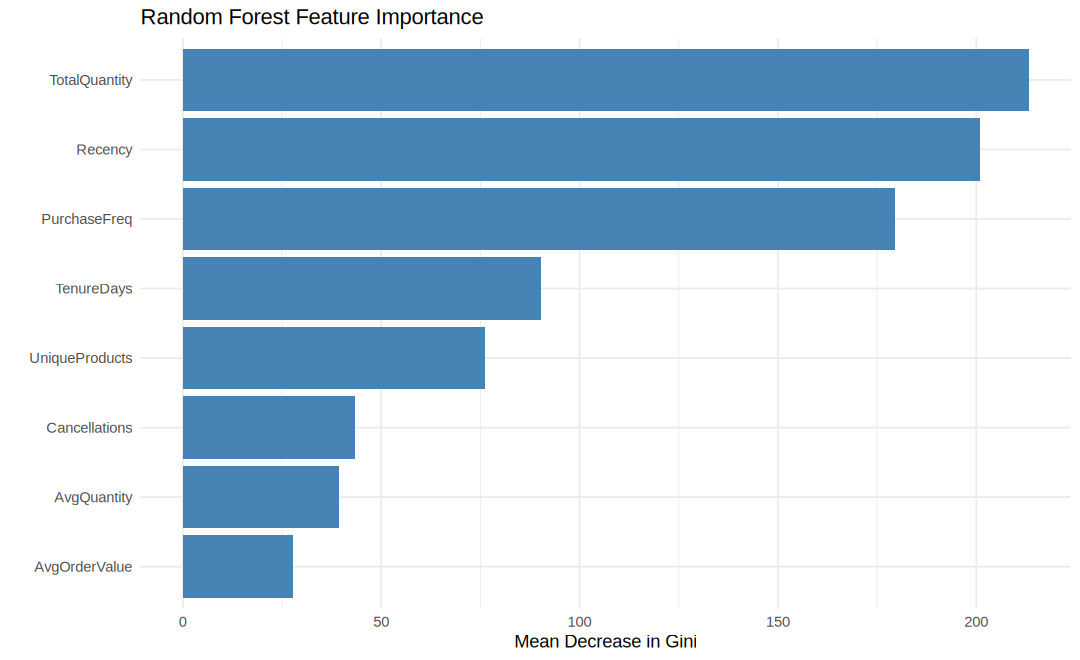

In [ ]:
imp <- as.data.frame(importance(rf))
imp$Feature <- rownames(imp)
print(imp[order(-imp$MeanDecreaseGini), c("Feature", "MeanDecreaseAccuracy", "MeanDecreaseGini")], row.names = FALSE)

ggplot(imp, aes(reorder(Feature, MeanDecreaseGini), MeanDecreaseGini)) +
  geom_col(fill = "steelblue") + coord_flip() + theme_minimal() +
  labs(title = "Random Forest Feature Importance", x = NULL, y = "Mean Decrease in Gini")

## 19. Auto-Generated Results Summary

In [ ]:
best <- results$Model[which.max(results$F1)]
cat("=========== RESULTS SUMMARY ===========\n")
cat("Customers analysed              :", nrow(cust), "\n")
cat("Clusters chosen (Elbow/Silhouette): k =", K, "\n")
cat("Silhouette  K-Means / Hierarchical:", round(sil_km, 3), "/", round(sil_hc, 3), "\n")
cat("Agreement between methods (ARI)  :", round(ari_val, 3), "\n")
cat("PCA variance explained (PC1+PC2)  :", round(sum(var_exp[2, 1:2]) * 100, 1), "%\n")
cat("High-value segment               :", seg_names[1], "-", prof$Customers[1], "customers (", prof$Pct[1], "%) generating",
    rev$Share[rev$Segment == seg_names[1]], "% of revenue\n")
cat("Best classifier (by F1)          :", best, "\n")
cat("Top predictive feature           :", imp$Feature[which.max(imp$MeanDecreaseGini)], "\n")

write.csv(cust, "customer_segments.csv", row.names = FALSE)
cat("\nSaved: customer_segments.csv, customer_clusters_3d.html\n")

=========== RESULTS SUMMARY ===========
Customers analysed              : 4334 
Clusters chosen (Elbow/Silhouette): k = 4 
Silhouette  K-Means / Hierarchical: 0.337 / 0.277 
Agreement between methods (ARI)  : 0.419 
PCA variance explained (PC1+PC2)  : 94 %
High-value segment               : Champions (High-Value) - 753 customers ( 17.4 %) generating 65.7 % of revenue
Best classifier (by F1)          : SVM (RBF) 
Top predictive feature           : TotalQuantity 

Saved: customer_segments.csv, customer_clusters_3d.html


## 20. Interpretation of Results
* **Number of clusters.** The elbow curve flattens after k ≈ 3–4 and the silhouette scores are highest for small k. k = 4 was chosen because it produces business-interpretable segments while keeping a reasonable silhouette value.
* **K-Means vs Hierarchical.** Both methods produce broadly similar groupings (see the cross-tabulation and Adjusted Rand Index). K-Means yields more balanced clusters and is scalable; Ward's hierarchical clustering exposes the nested structure in the dendrogram but is O(n²) in memory.
* **PCA.** The first two components capture most of the variance (see scree plot), so the 2D projection is a faithful view; Recency loads in the opposite direction to Frequency/Monetary, separating active from dormant customers.
* **Segments.** A small *Champions* group produces a disproportionately large share of revenue (Pareto effect), while the *Lost/Dormant* group has high recency (long inactivity) and low spend.
* **Prediction.** Both Random Forest and SVM identify high-value customers with high accuracy and AUC. Because the label comes from clustering, high performance is expected; see the leakage note in Section 16. Random Forest additionally reveals which behaviours (order value, quantity, product variety, purchase rate) drive high-value status.
* **Limitations.** Single retailer, 12 months, clustering is unsupervised (no ground truth), and the classification target is derived from the clusters.

## 21. Segment-Wise Marketing Recommendations
| Segment | Profile | Recommended strategy |
|---|---|---|
| **Champions (High-Value)** | Very recent, frequent, highest spend and basket size | VIP/loyalty tier, early access to new products, personalised offers, referral rewards; avoid heavy discounting – protect margin |
| **Loyal Customers** | Regular purchasers, moderate-to-high spend | Cross-sell and bundles, subscription/replenishment reminders, points-based rewards to move them up to Champions |
| **At-Risk / Occasional** | Purchased some time ago, low frequency | Win-back e-mail with time-limited discount, "we miss you" campaign, product recommendations based on past purchases |
| **Lost / Dormant** | Long inactive, lowest spend | Low-cost reactivation (one final coupon), survey to learn why they left, then suppress from paid campaigns to save budget |

*General:* use the classifier to score new customers early and route likely high-value customers into the VIP journey; re-run the segmentation quarterly.

## 22. Conclusion
In this experiment, transactional data from the UCI Online Retail dataset was cleaned (missing customers, cancellations, invalid values, duplicates removed) and converted into customer-level RFM and behavioural features, with outliers winsorised, skewness reduced by log transformation and features standardised. K-Means with the Elbow Method and Silhouette analysis identified k = 4 customer segments, which were validated against Ward's hierarchical clustering and visualised with 2D PCA and an interactive 3D Plotly chart. Cluster profiling identified a compact high-value *Champions* segment contributing a large share of revenue. Random Forest and SVM classifiers were trained and evaluated with Accuracy, Precision, Recall, F1-score, ROC-AUC and confusion matrices, and Random Forest feature importance showed the behaviours that distinguish high-value customers. Finally, segment-specific marketing strategies were proposed. The experiment demonstrates a complete, industry-style data-science workflow in R, from raw data to business action.

